In [3]:
# fix file
import os

def fix_file(filepath):
    bad_filepath = '/'.join(filepath.split('/')[:-1]) + '/_' + filepath.split('/')[-1]
    if not os.path.exists(bad_filepath):
        os.rename(filepath, bad_filepath)
    elif not os.path.samefile(filepath, bad_filepath):
        os.remove(bad_filepath)
        os.rename(filepath, bad_filepath)
    print(bad_filepath)
    with open(filepath, 'w') as new_file:
        bad_file = open(bad_filepath, 'r')
        line = bad_file.readline()
        while line:
            if line.endswith('; \n') or line.endswith('; '):
                new_file.write(line[:-3] + '\n')
            else: new_file.write(line)
            line = bad_file.readline()

# file = './results/final_datasets/results_diff_2024-02-20T100948.txt'
# file = './results/final_datasets/results_no_diff_2024-02-19T105846.txt'

# file = './results/final_datasets/results_diffNN_2024-02-24T193319.txt'
# file = './results/final_datasets/results_diffNN_2024-02-25T160224.txt'
# for file in os.listdir("./results/final_datasets_rnn"):
#     if ".txt" in file: fix_file("./results/final_datasets_rnn/" + file)

./results/final_datasets_rnn/_results_rand_2024-04-02T105654.txt
./results/final_datasets_rnn/_results_rand_2024-04-02T111943.txt
./results/final_datasets_rnn/_results_rand_2024-04-03T155223.txt
./results/final_datasets_rnn/_results_rand_2024-04-03T194426.txt
./results/final_datasets_rnn/_results_rand_2024-04-06T165844.txt
./results/final_datasets_rnn/_results_rand_2024-04-06T184051.txt
./results/final_datasets_rnn/_results_rand_2024-04-06T184817.txt
./results/final_datasets_rnn/_results_rand_2024-04-06T190620.txt


In [3]:
import pandas as pd
import numpy as np

labels = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []
dfs.append(pd.read_csv('results/final_datasets2/results_rand_2024-03-01T125901.txt', header=3, sep=';', names=labels))
# df1 = pd.read_csv('results/final_datasets2/results_rand_2024-03-01T125901.txt', header=3, sep=';', names=labels)
dfs.append(pd.read_csv('results/final_datasets2/results_rand_2024-03-02T162128.txt', header=3, sep=';', names=labels))
# df2 = pd.read_csv('results/final_datasets2/results_rand_2024-03-02T162128.txt', header=3, sep=';', names=labels)

# df1 = pd.read_csv('./results/final_datasets/results_diffNN_2024-02-24T193319.txt', header=3, sep=';', names=labels)
# df2 = pd.read_csv('./results/final_datasets/results_diffNN_2024-02-25T160224.txt', header=3, sep=';', names=labels)
dfs.append(pd.concat((pd.read_csv('./results/final_datasets2/results_rand_2024-03-03T183737.txt', header=3, sep=';', names=labels),
                 pd.read_csv('./results/final_datasets2/results_rand_2024-03-04T140048.txt', header=3, sep=';', names=labels))))
# df3 = pd.concat((pd.read_csv('./results/final_datasets2/results_rand_2024-03-03T183737.txt', header=3, sep=';', names=labels),
#                  pd.read_csv('./results/final_datasets2/results_rand_2024-03-04T140048.txt', header=3, sep=';', names=labels)))
dfs[2] = dfs[2].reset_index(drop=True)

dfs.append(pd.read_csv('results/final_datasets2/results_rand_2024-03-05T123438.txt', header=3, sep=';', names=labels))


# print(df.shape)
for df in dfs:
    df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

    df.insert(1, 'h', list(map(len, df['Architechture'])))
    df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

    print(df.shape)
# print(df.columns)
# df.rename(columns={'Architechture': "Arch", " % of train dataset": "ratio"})
# print(np.array(df['Architechture']))


(256, 13)
(256, 13)
(256, 13)
(256, 13)


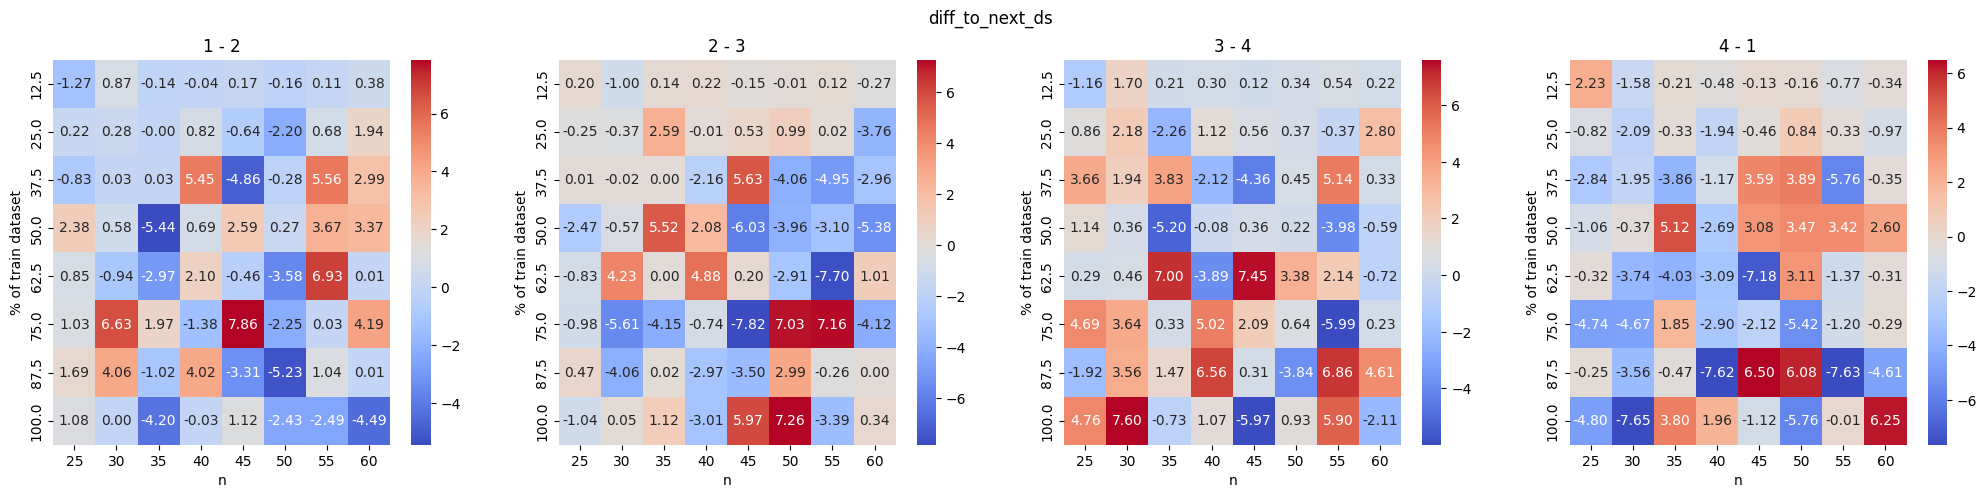

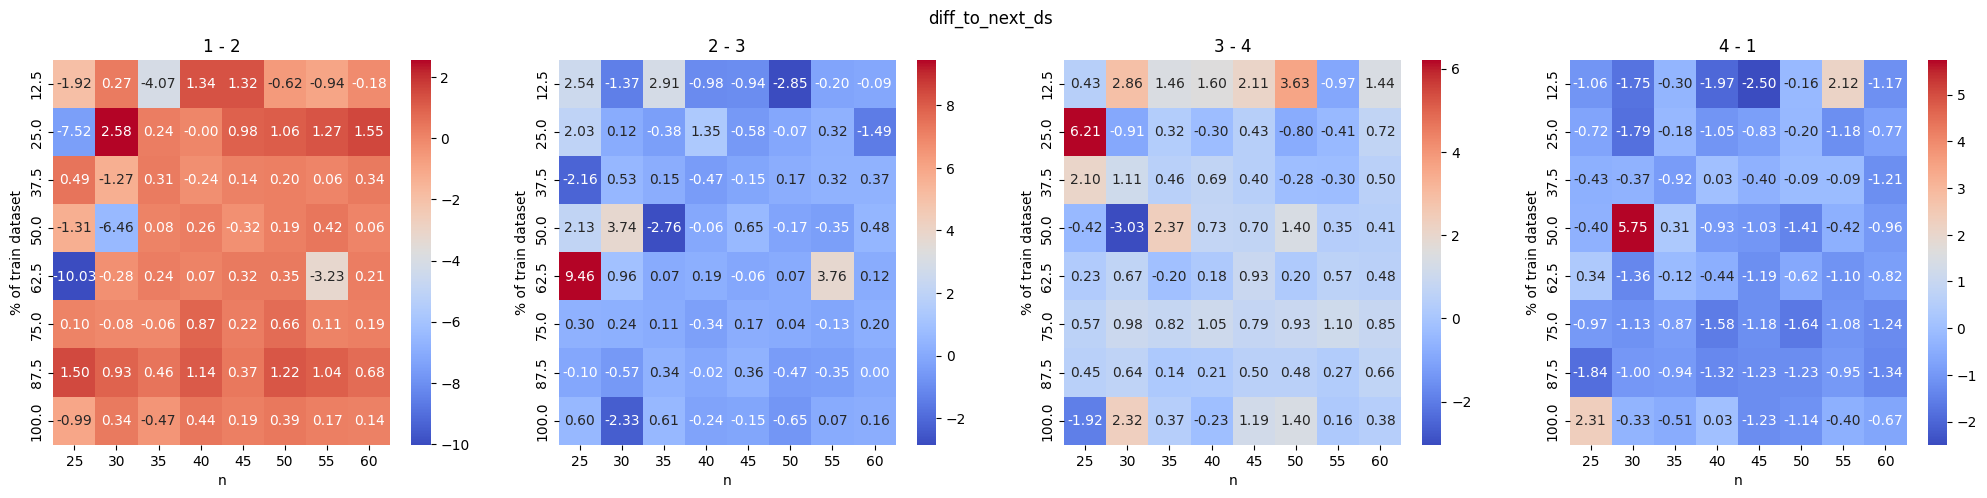

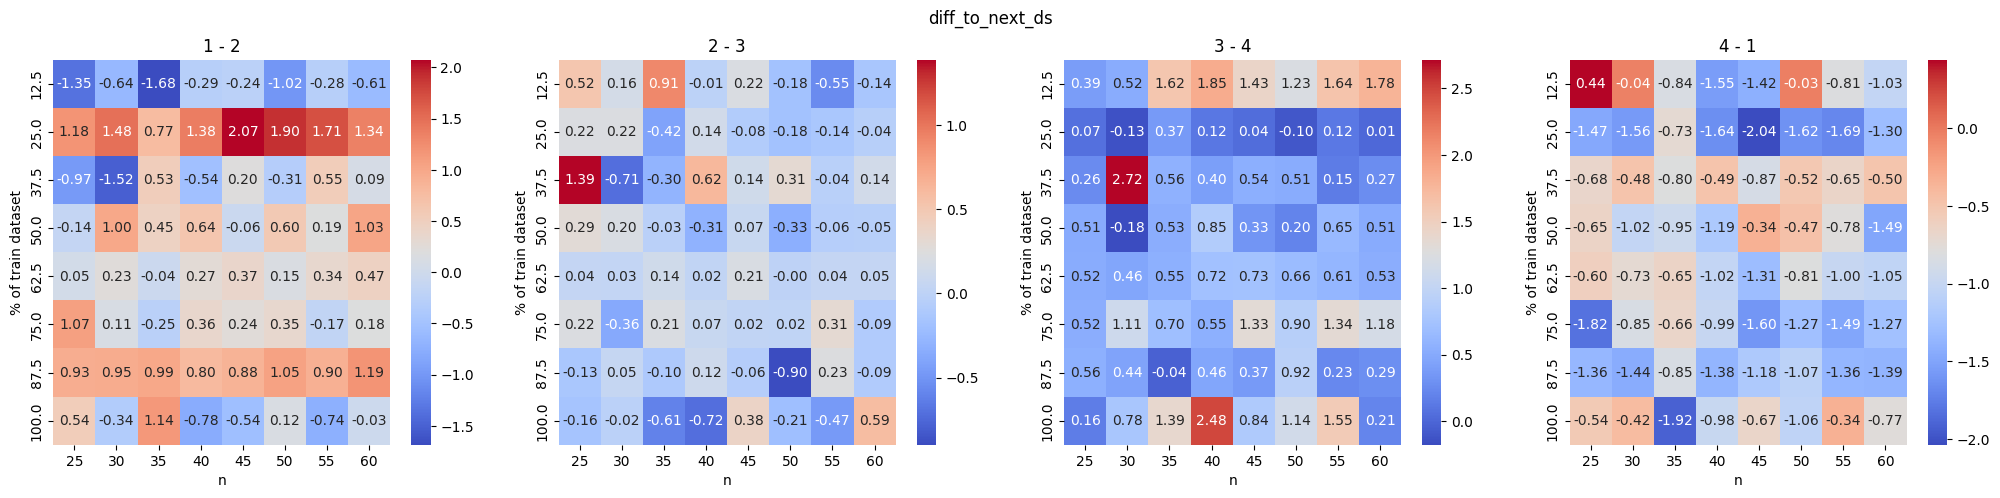

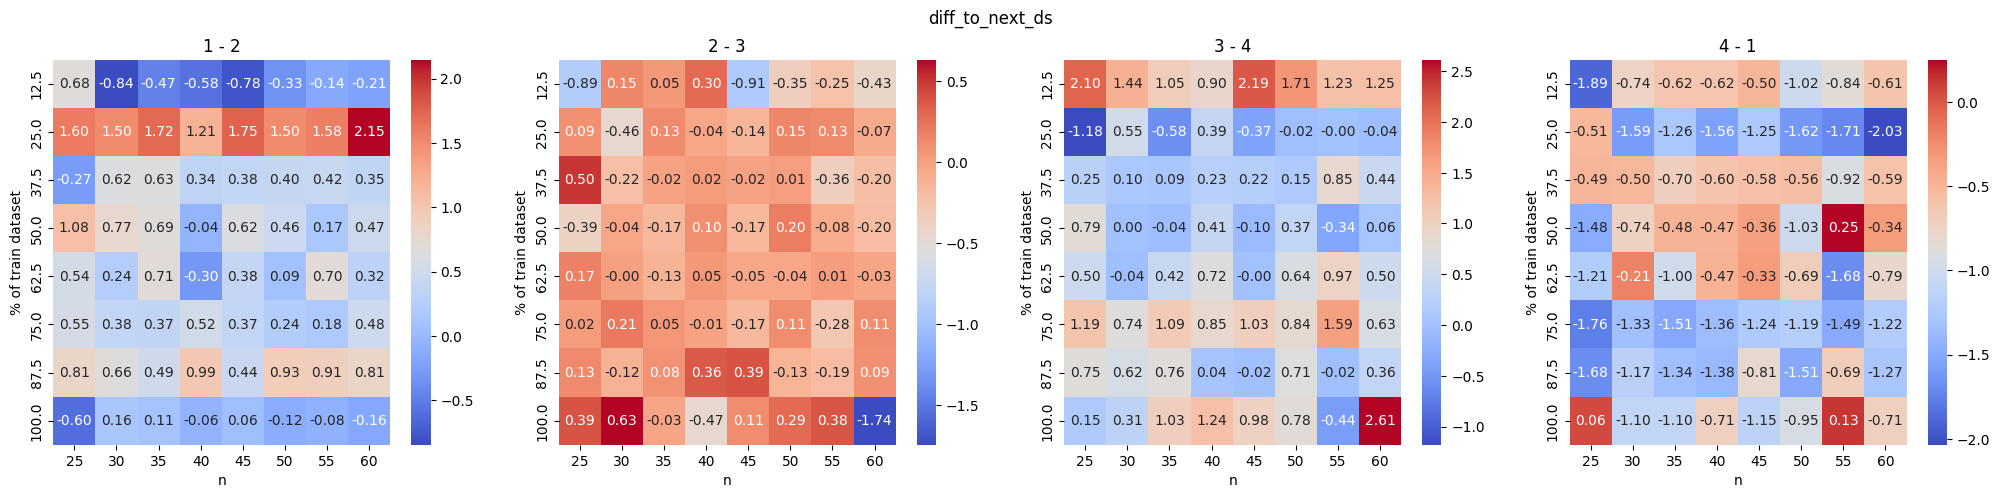

In [59]:
# tests diff
import seaborn as sns
import matplotlib.pyplot as plt

for i in range(len(dfs)-1):
    dfs[i]['diff_to_next'] = dfs[i]['MAE [mm]'] - dfs[i+1]['MAE [mm]']

dfs[-1]['diff_to_next'] = dfs[-1]['MAE [mm]'] - dfs[0]['MAE [mm]']

# dfs[0]['diff_to_next'] = dfs[0]['MAE [mm]'] - dfs[1]['MAE [mm]']
# dfs[1]['diff_to_next'] = dfs[1]['MAE [mm]'] - dfs[2]['MAE [mm]']
# dfs[2]['diff_to_next'] = dfs[2]['MAE [mm]'] - dfs[0]['MAE [mm]']

for h in set(dfs[0]['h']):
    fig, ax = plt.subplots(1, len(dfs), figsize=(25,5))
    fig.suptitle('diff_to_next_ds')
    for i, df in enumerate(dfs):
        heatmap_data = df[df['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='diff_to_next')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[i])
        ax[i].set_xlabel('n')
        ax[i].set_ylabel(r'% of train dataset')
        if i == len(dfs) - 1: ax[i].set_title(f'{i+1} - 1')
        else: ax[i].set_title(f'{i+1} - {i+2}')


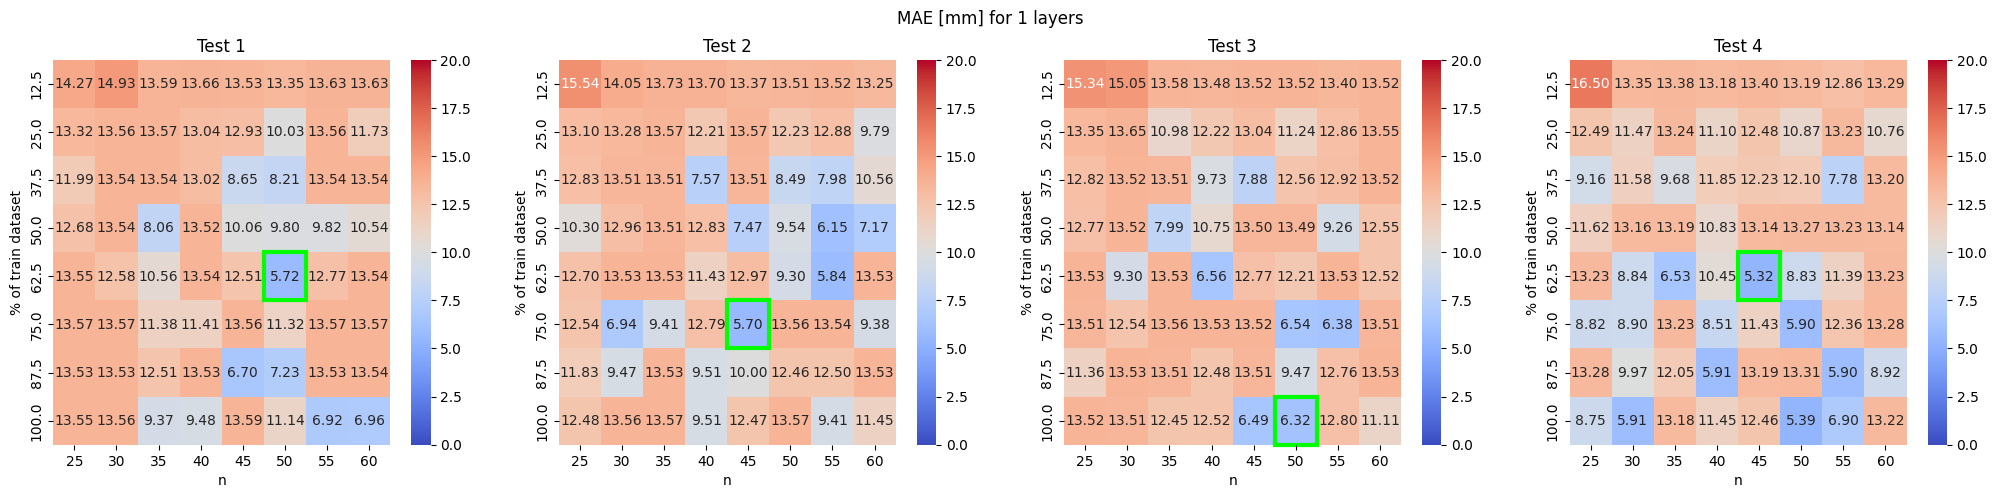

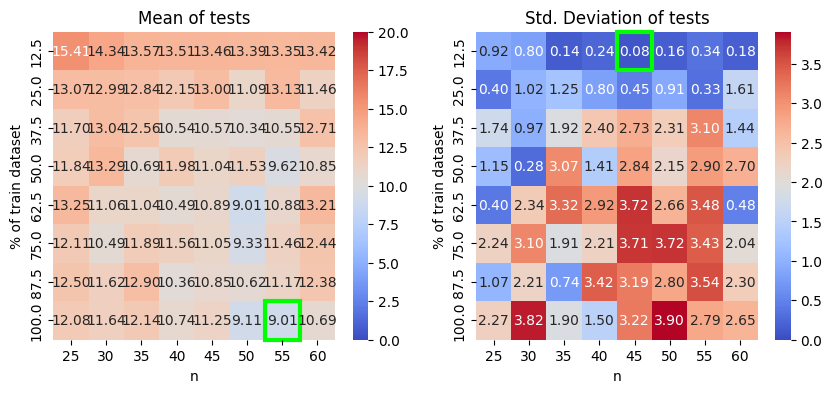

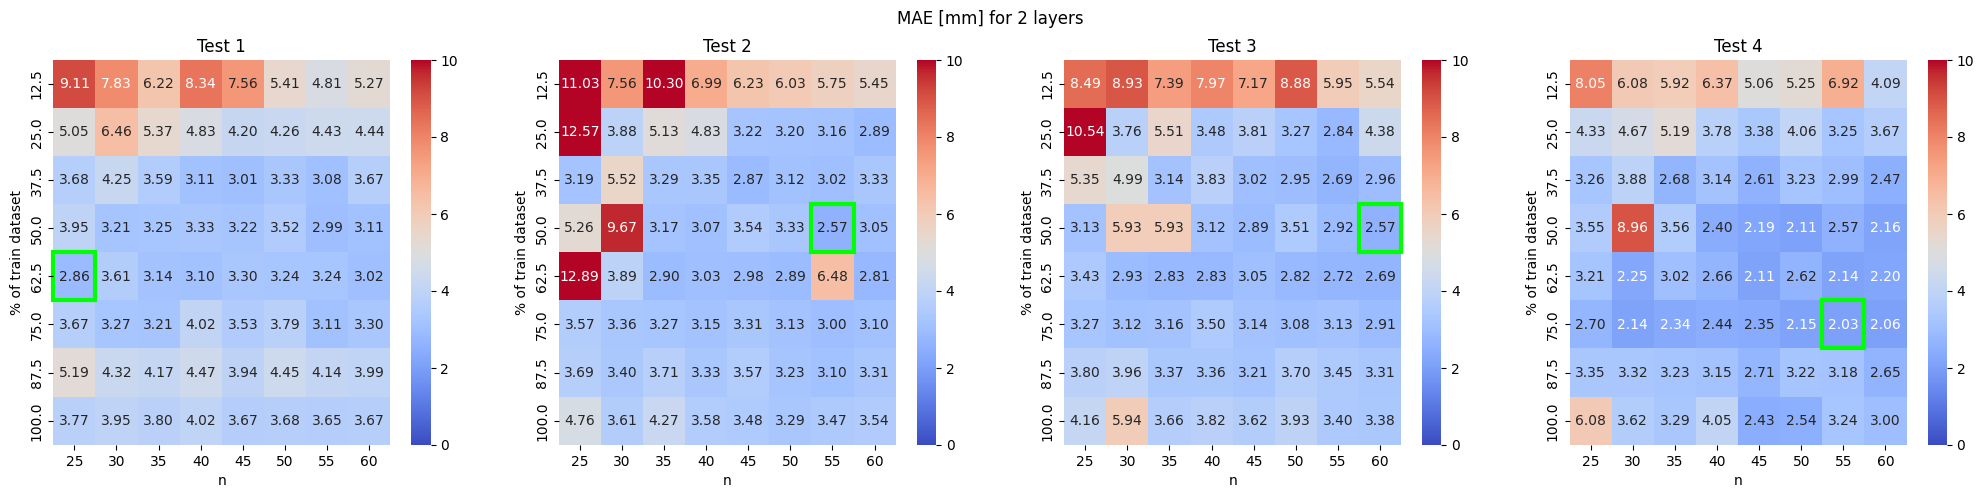

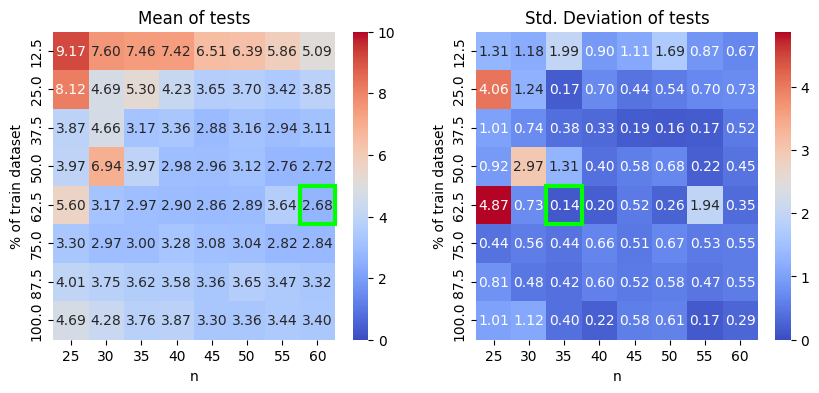

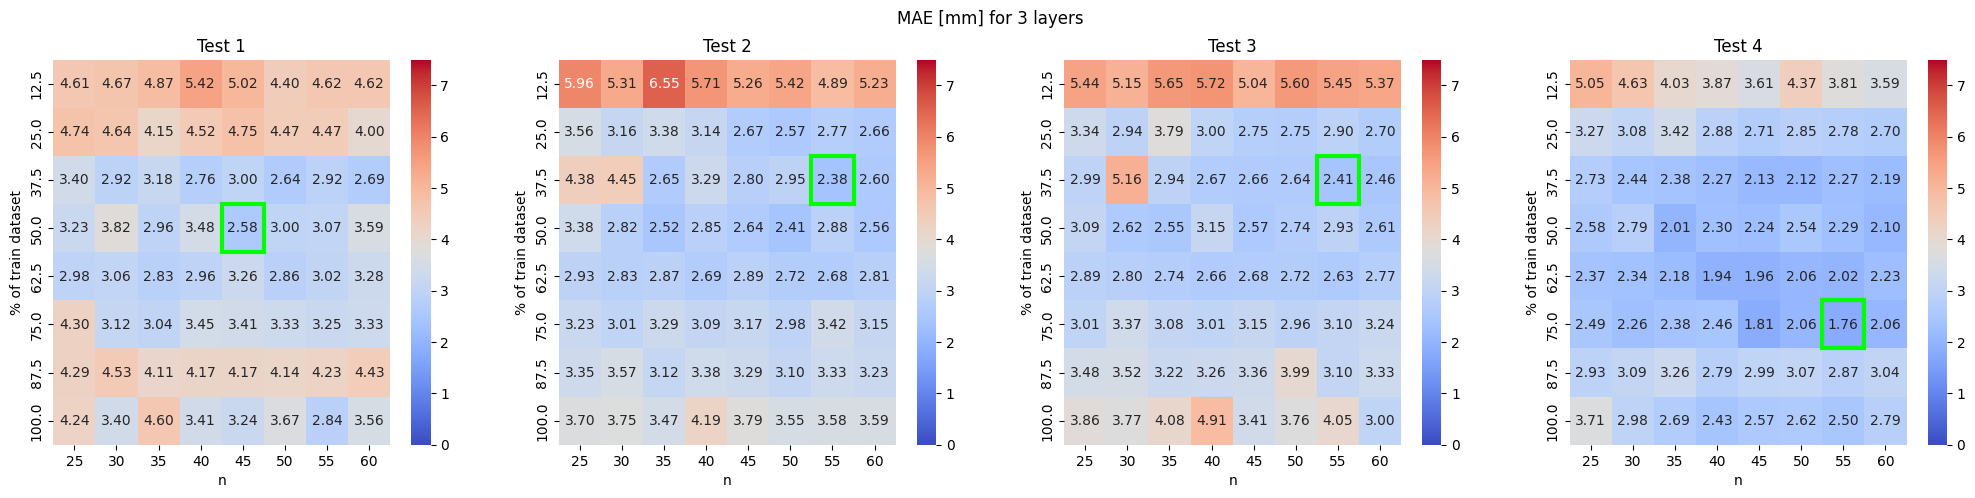

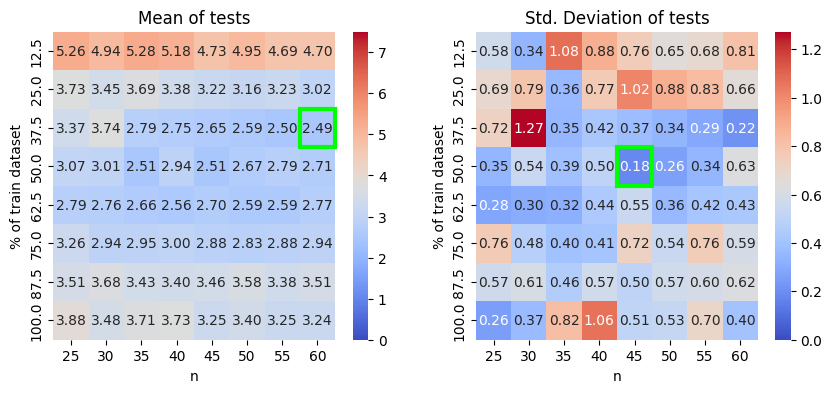

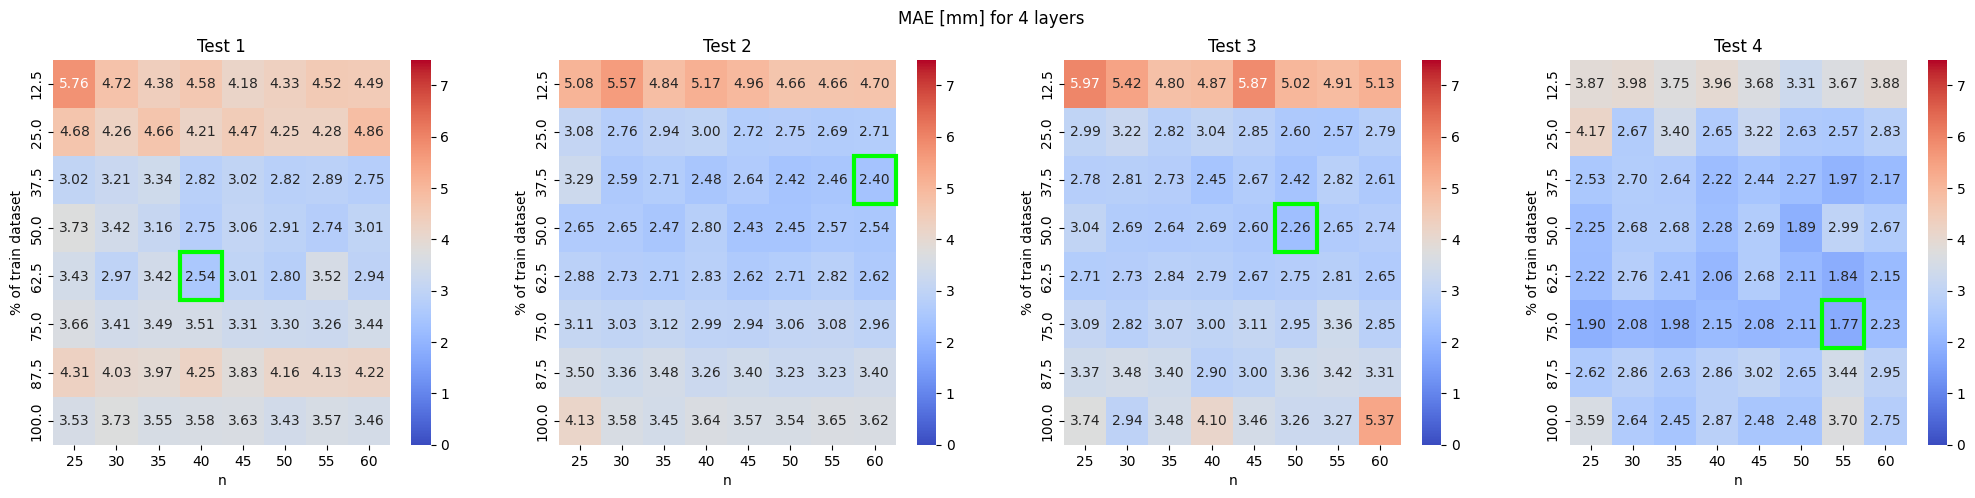

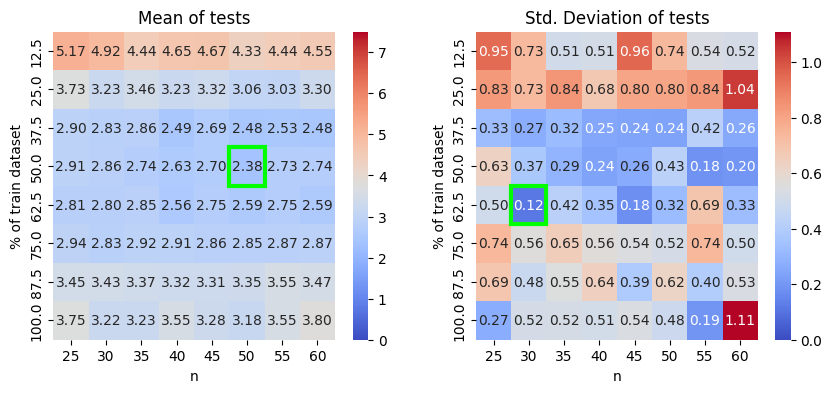

In [70]:
# tests compare
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

for i in range(len(dfs)-1):
    dfs[i]['diff_to_next'] = dfs[i]['MAE [mm]'] - dfs[i+1]['MAE [mm]']

dfs[-1]['diff_to_next'] = dfs[-1]['MAE [mm]'] - dfs[0]['MAE [mm]']

# dfs[0]['diff_to_next'] = dfs[0]['MAE [mm]'] - dfs[1]['MAE [mm]']
# dfs[1]['diff_to_next'] = dfs[1]['MAE [mm]'] - dfs[2]['MAE [mm]']
# dfs[2]['diff_to_next'] = dfs[2]['MAE [mm]'] - dfs[0]['MAE [mm]']

vmaxs = [0, 20, 10, 7.5, 7.5]
dfs_concat = pd.concat(dfs)
for h in set(dfs[0]['h']):
    fig, ax = plt.subplots(1, len(dfs), figsize=(25,5))
    fig.suptitle(f'MAE [mm] for {h} layers')
    for i, df in enumerate(dfs):
        heatmap_data = df[df['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[i], vmin=0, vmax=vmaxs[h])
        ax[i].set_xlabel('n')
        ax[i].set_ylabel(r'% of train dataset')
        ax[i].set_title(f'Test {i+1}')
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        ax[i].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].set_title('Mean of tests')
    ax[1].set_title('Std. Deviation of tests')
    
    heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
    sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[0], vmin=0, vmax=vmaxs[h])
    min_idx = heatmap_data.stack().idxmin()
    row_idx, col_idx = min_idx
    ax[0].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
    
    heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='std')
    sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], vmin=0)
    min_idx = heatmap_data.stack().idxmin()
    row_idx, col_idx = min_idx
    ax[1].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))

    ax[0].set_xlabel('n')
    ax[0].set_ylabel(r'% of train dataset')
    ax[1].set_xlabel('n')
    ax[1].set_ylabel(r'% of train dataset')


    


models: rand
./results/final_datasets2/results_rand_2024-03-01T125901.txt
./results/final_datasets2/results_rand_2024-03-03T183737.txt
./results/final_datasets2/results_rand_2024-03-02T162128.txt
./results/final_datasets2/results_rand_2024-03-05T123438.txt
./results/final_datasets2/results_rand_2024-03-11T130434.txt 
 ./results/final_datasets3/results_rand_2024-03-25T112649.txt
./results/final_datasets3/results_rand_2024-03-25T222051.txt
./results/final_datasets3/results_rand_2024-03-26T112415.txt
./results/final_datasets3/results_rand_2024-03-27T153256.txt
./results/final_datasets3/results_rand_2024-03-27T201424.txt
./results/final_datasets3/results_rand_2024-04-03T151839.txt


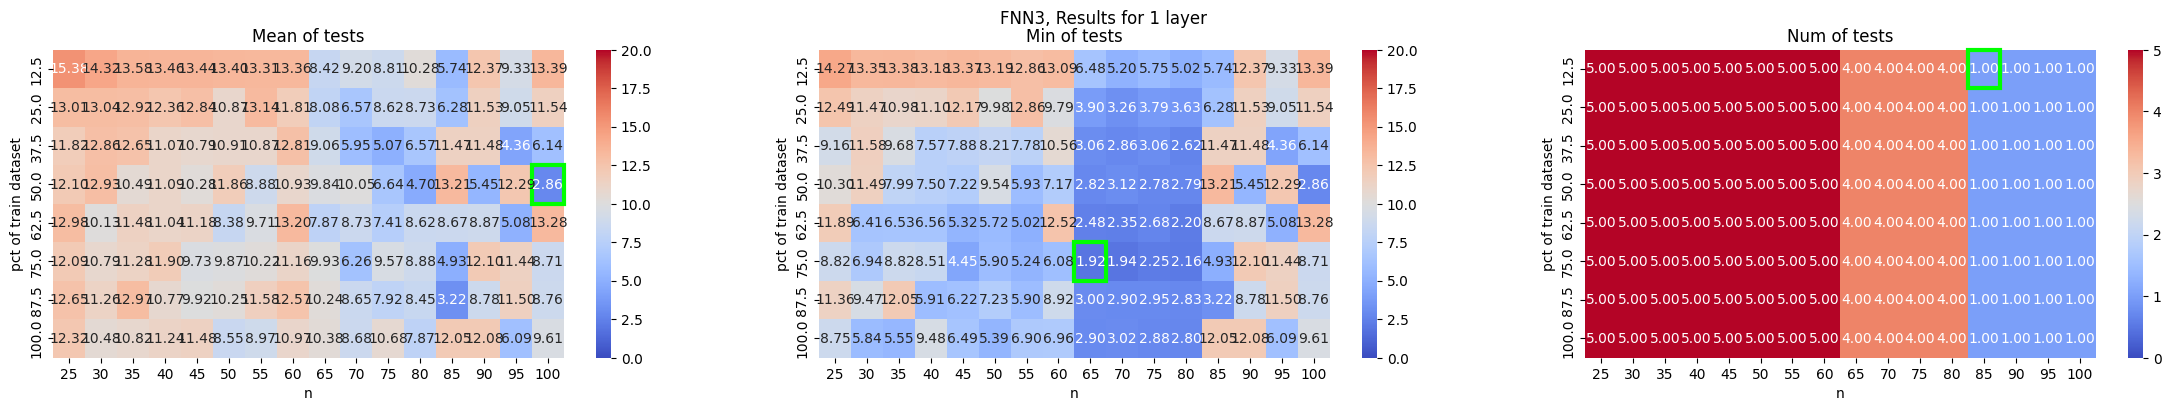

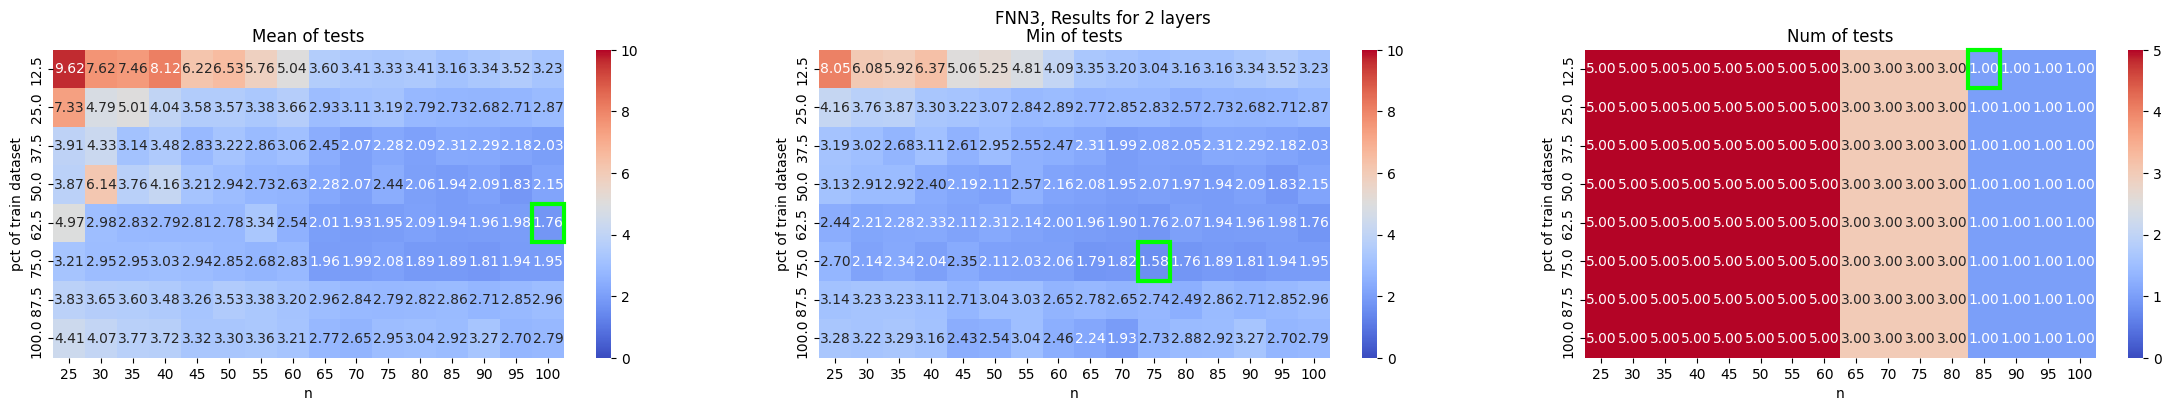

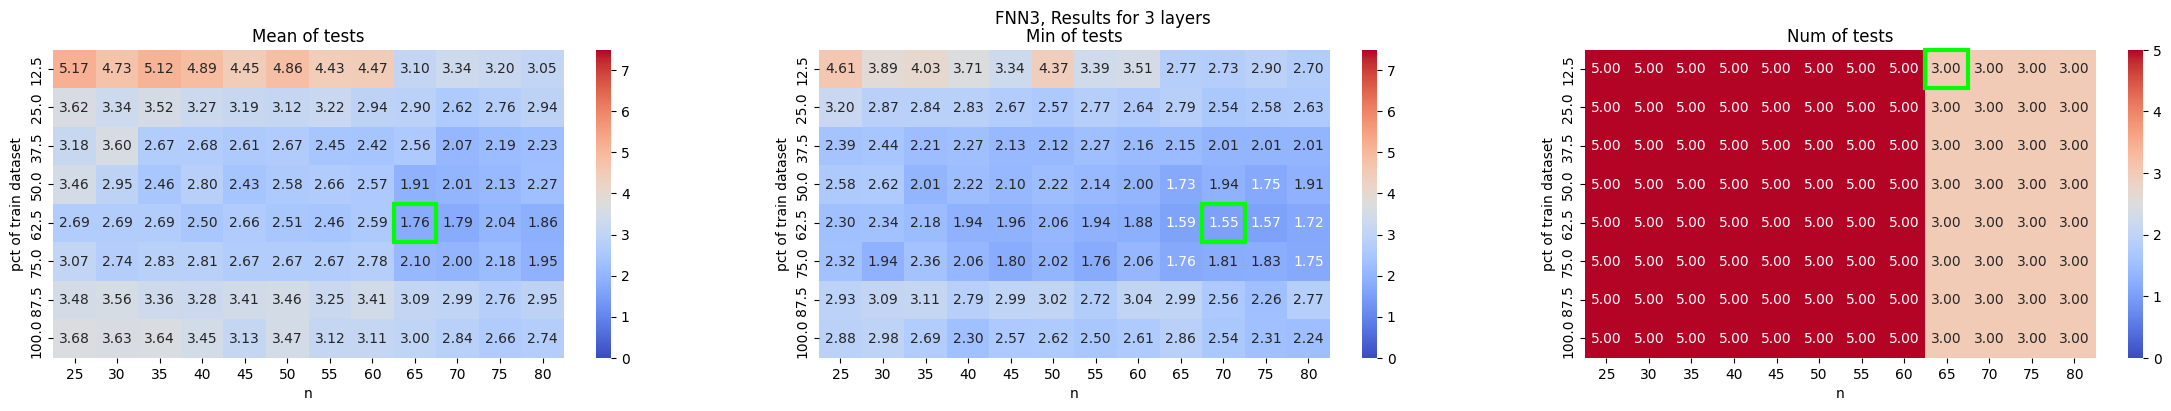

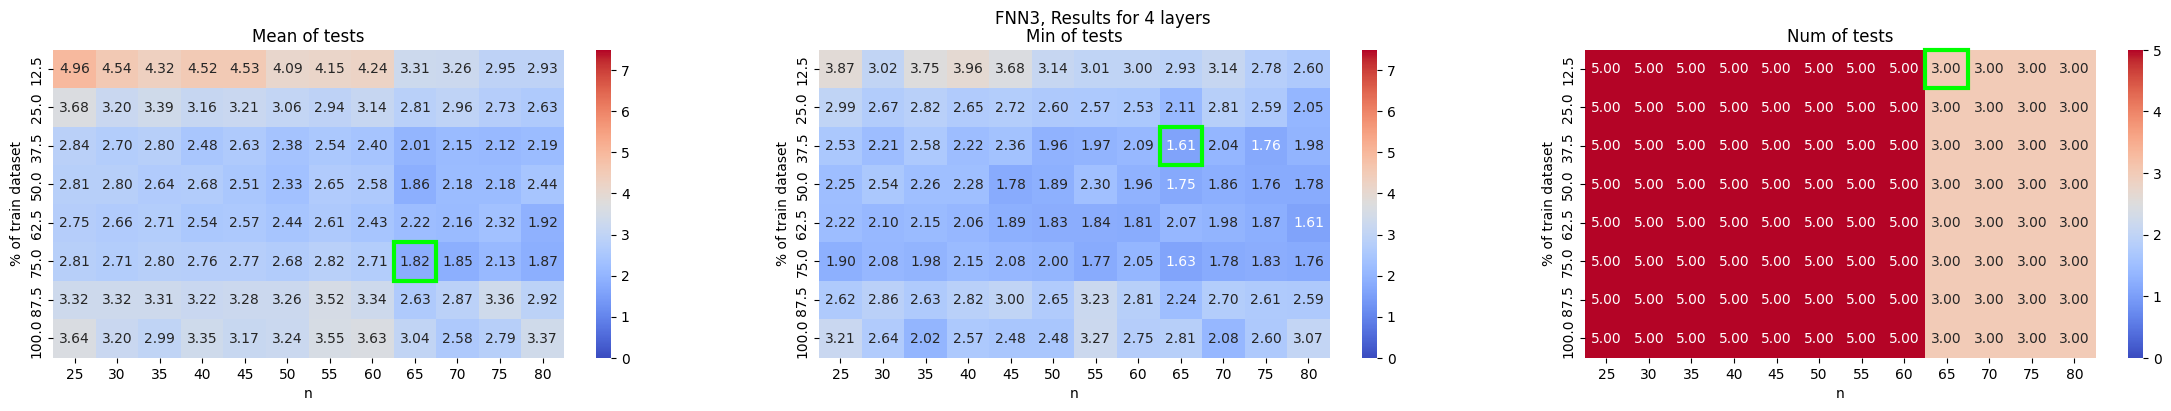

In [2]:
# tests mean and min

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = True
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

models = ["rand"]
# models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
models_title = ["FNN3"]
result_files = ["./results/final_datasets2/" + file for file in os.listdir("./results/final_datasets2") if ".txt" in file and "_results" not in file] + \
    ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# models = ["diff_rand"]
# models_title = ["FNN6"]
# result_files = ["./results/final_datasets3/results_diff_rand_2024-04-09T130207.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-10T101624.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-11T114825.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-12T114550.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-12T130323.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-13T100152.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-13T191150.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-14T231148.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-15T110531.txt"
#                 ]
# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

vmaxs = [0, 20, 10, 7.5, 7.5]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if "./results/final_datasets2/" in file
           and ("results_" + model + "_2024") in file]
    
    result_files3 = [file for file in result_files if "./results/final_datasets3/" in file
           and ("results_" + model + "_2024") in file]
    
    print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] + \
        [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]
            df.insert(1, 'h', list(map(len, df['Architechture'])))
            df.insert(1, 'n', [arch[0] for arch in df['Architechture']])
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    for h in set(dfs_concat["h"]):
        fig, ax = plt.subplots(1, 3, figsize=(28, 4))
        if h > 1: s = 's'
        else: s = ''
        # fig.suptitle(f"Data: {models_title[i]}, Results for {h} layer{s}")
        fig.suptitle(f"{models_title[i]}, Results for {h} layer{s}")
        ax[0].set_title('Mean of tests')
        ax[1].set_title('Min of tests')
        # ax[2].set_title('Std. Deviation of tests')
        ax[2].set_title('Num of tests')
        
        # try:
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[0], vmin=0, vmax=vmaxs[h])
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        ax[0].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min', fill_value=True)
        heatmap_data.replace(True, np.nan, inplace=True)
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], vmin=0, vmax=vmaxs[h])
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        ax[1].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc=np.argmin)
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count')
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='std')
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.0f', ax=ax[2], vmin=0)
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[2], vmin=0)
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        ax[2].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # except Exception as e:
        #     print("failed plots:", e)
        #     continue

    ax[0].set_xlabel('n')
    ax[0].set_ylabel(r'% of train dataset')
    ax[1].set_xlabel('n')
    ax[1].set_ylabel(r'% of train dataset')
    ax[2].set_xlabel('n')
    ax[2].set_ylabel(r'% of train dataset')
    # print(" ", file)

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[0]}_plots')
        # print(plots_folder)
        if not os.path.exists(plots_folder): os.mkdir(plots_folder)
        if isinstance(ax, plt.Axes):
            fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_min_mae.pgf")
        else:
            fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_all.pgf")



models: diff_rand
 
 ./results/final_datasets3/results_diff_rand_2024-04-09T130207.txt
./results/final_datasets3/results_diff_rand_2024-04-10T101624.txt
./results/final_datasets3/results_diff_rand_2024-04-11T114825.txt
./results/final_datasets3/results_diff_rand_2024-04-12T114550.txt
./results/final_datasets3/results_diff_rand_2024-04-12T130323.txt
./results/final_datasets3/results_diff_rand_2024-04-13T100152.txt
./results/final_datasets3/results_diff_rand_2024-04-13T191150.txt
./results/final_datasets3/results_diff_rand_2024-04-14T231148.txt
./results/final_datasets3/results_diff_rand_2024-04-15T110531.txt
1L min_idx (np.float64(87.5), np.int64(45))
min_err: 3.981 ; rel_err 3.1721115537848608
2L min_idx (np.float64(62.5), np.int64(65))
min_err: 2.501 ; rel_err 1.9928286852589643
3L min_idx (np.float64(62.5), np.int64(50))
min_err: 2.5006666666666666 ; rel_err 1.9925630810092962
4L min_idx (np.float64(62.5), np.int64(80))
min_err: 2.378 ; rel_err 1.8948207171314744


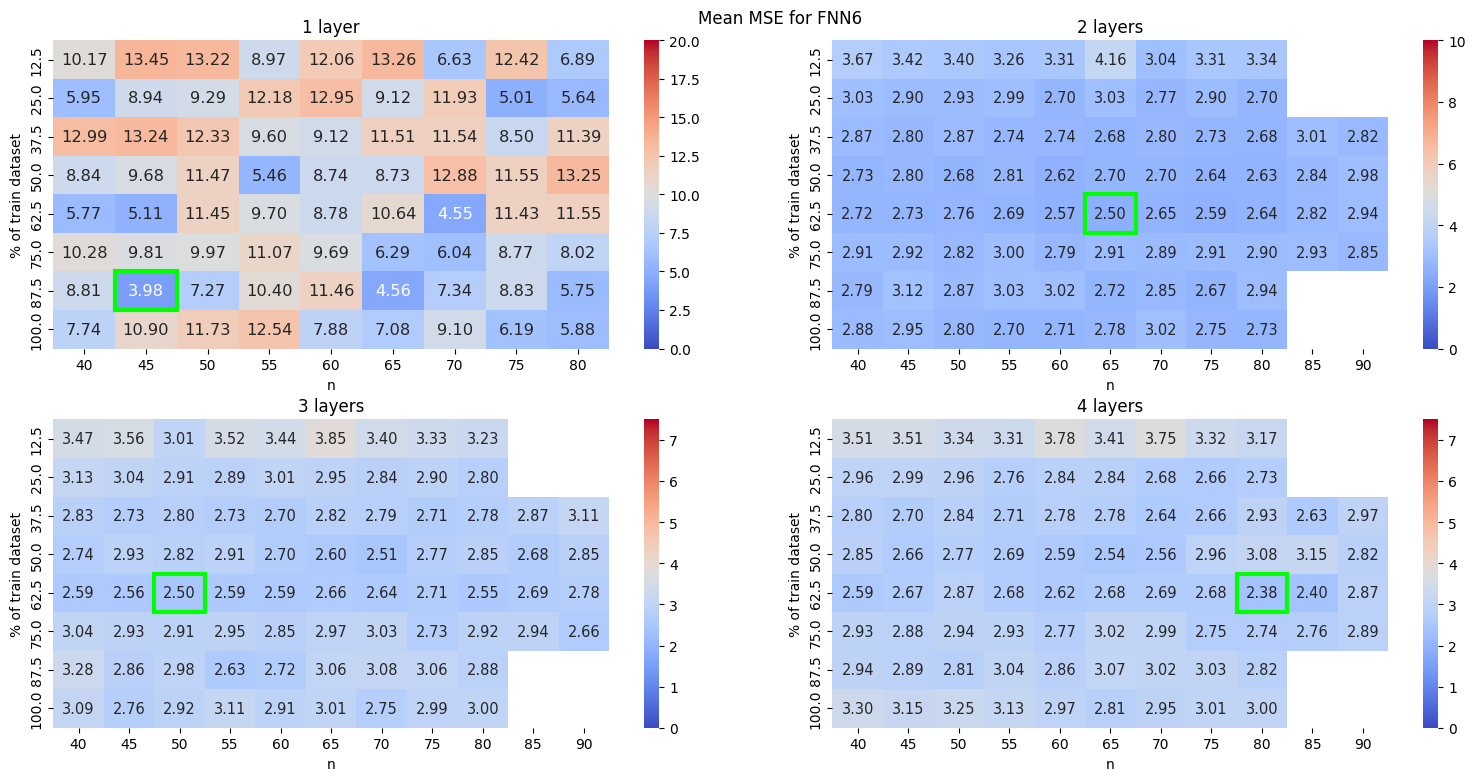

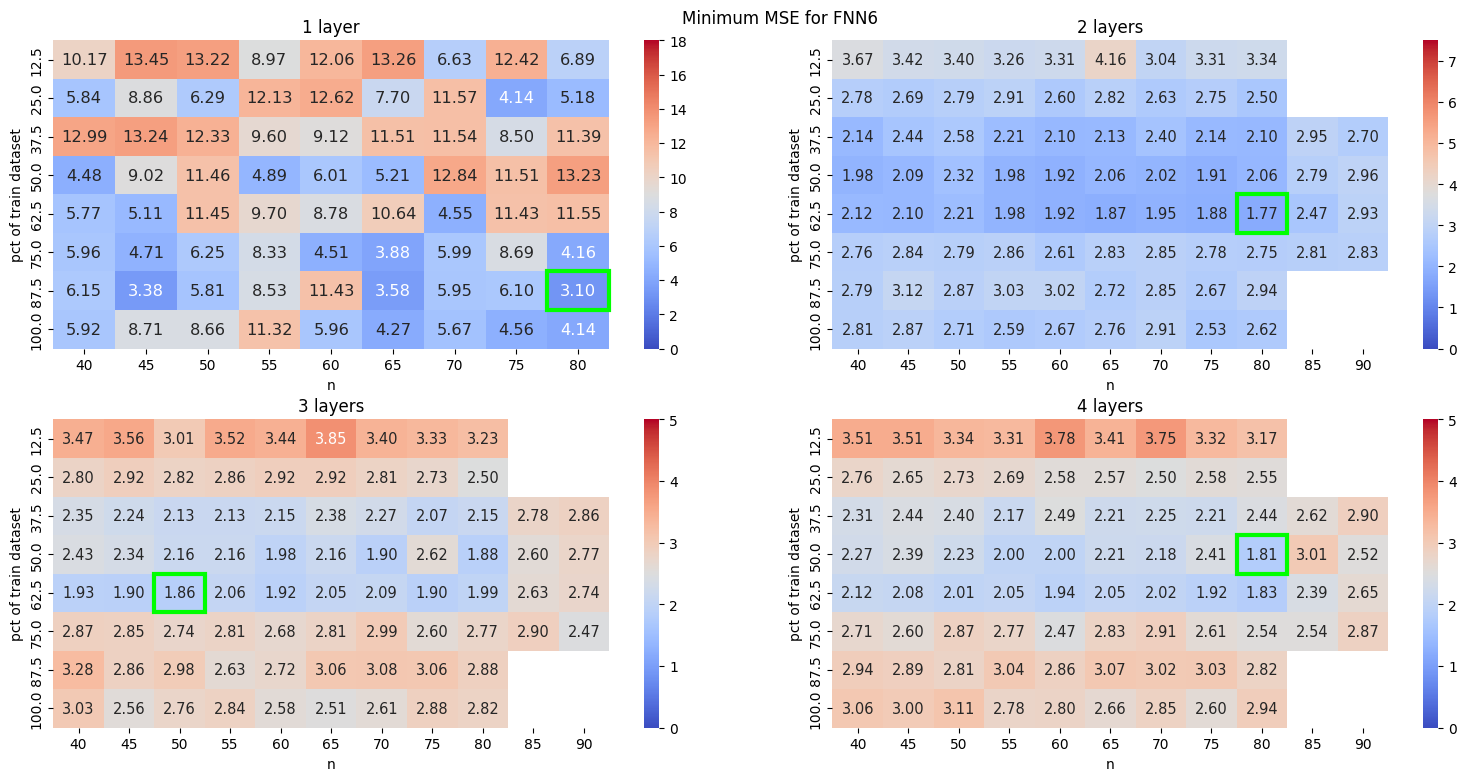

In [ ]:
# tests mean and min, layers together, FNN

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = False
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

# models = ["rand"]
# folder = "./results/final_datasets3/"
# # models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
# models_title = ["FNN3"]
# result_files = ["./results/final_datasets2/" + file for file in os.listdir("./results/final_datasets2") if ".txt" in file and "_results" not in file] + \
#     ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

models = ["diff_rand"]
folder = "./results/final_datasets3/"
models_title = ["FNN6"]
result_files = ["./results/final_datasets3/results_diff_rand_2024-04-09T130207.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-10T101624.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-11T114825.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-12T114550.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-12T130323.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-13T100152.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-13T191150.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-14T231148.txt",
                "./results/final_datasets3/results_diff_rand_2024-04-15T110531.txt"
                ]

# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

mean_vmaxs = [0, 20, 10, 7.5, 7.5]
min_vmaxs = [0, 18, 7.5, 5, 5]
# mean_vmaxs = [0, 10, 10, 10, 10]
# min_vmaxs = [0, 18, 7.5, 5, 5]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if "./results/final_datasets2/" in file
           and ("results_" + model + "_2024") in file]
    
    result_files3 = [file for file in result_files if "./results/final_datasets3/" in file
           and ("results_" + model + "_2024") in file]
    
    print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] + \
        [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]
            df.insert(1, 'h', list(map(len, df['Architechture'])))
            df.insert(1, 'n', [arch[0] for arch in df['Architechture']])
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    # mean_fig, mean_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    mean_fig, mean_ax = plt.subplots(2, len(set(dfs_concat["h"]))//2, figsize=(16, 8))
    mean_ax = mean_ax.flatten()
    mean_fig.tight_layout(pad=3)
    mean_fig.suptitle(f"Mean MSE for {models_title[i]}")
    # min_fig, min_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    min_fig, min_ax = plt.subplots(2, len(set(dfs_concat["h"]))//2, figsize=(16, 8))
    min_fig.tight_layout(pad=3)
    min_ax = min_ax.flatten()
    min_fig.suptitle(f"Minimum MSE for {models_title[i]}")
    for j, h in enumerate(set(dfs_concat["h"])):
        if h > 1: s = 's'
        else: s = ''
        mean_ax[j].set_title(f"{h} layer{s}")
        min_ax[j].set_title(f"{h} layer{s}")
        
        # try:
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=mean_ax[j], vmin=0, vmax=mean_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        print(f'{h}L min_idx {min_idx}')
        print('min_err:', heatmap_data.loc[row_idx, col_idx], '; rel_err', heatmap_data.loc[row_idx, col_idx] / 1.255)
        mean_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=min_ax[j], vmin=0, vmax=min_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        min_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min', fill_value=True)
        # heatmap_data.replace(True, np.nan, inplace=True)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], vmin=0, vmax=vmaxs[h])
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[1].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        # # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc=np.argmin)
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count')
        # # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='std')
        # # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.0f', ax=ax[2], vmin=0)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[2], vmin=0)
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[2].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # except Exception as e:
        #     print("failed plots:", e)
        #     continue

        mean_ax[j].set_xlabel('n')
        mean_ax[j].set_ylabel(r'% of train dataset')
    # print(" ", file)

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[0].lower()}_plots')
        # print(plots_folder)
        if not os.path.exists(plots_folder): os.mkdir(plots_folder)
        # if isinstance(ax, plt.Axes):
        #     fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_min_mae.pgf")
        # else:
        #     fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_all.pgf")
        mean_fig.savefig(plots_folder + f"/{models_title[0].lower()}_mean_mea.pgf")
        min_fig.savefig(plots_folder + f"/{models_title[0].lower()}_min_mea.pgf")



models: rand
4
1L min_idx (np.float64(100.0), np.int64(50))
min_err: 2.831 ; rel_err 2.255776892430279
2L min_idx (np.float64(87.5), np.int64(20))
min_err: 2.412 ; rel_err 1.9219123505976097
3L min_idx (np.float64(87.5), np.int64(30))
min_err: 2.758 ; rel_err 2.197609561752988
4L min_idx (np.float64(100.0), np.int64(30))
min_err: 3.112666666666667 ; rel_err 2.4802124833997348


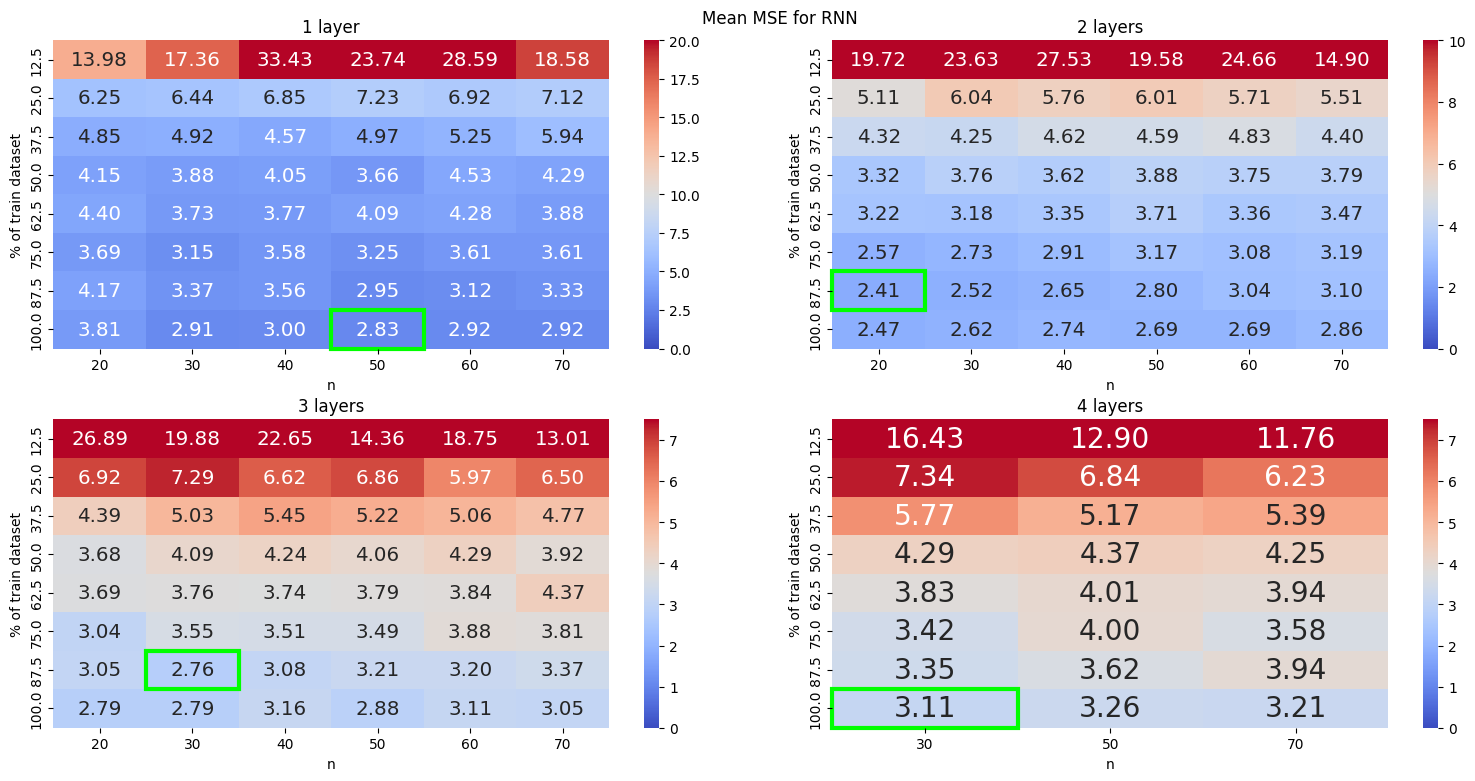

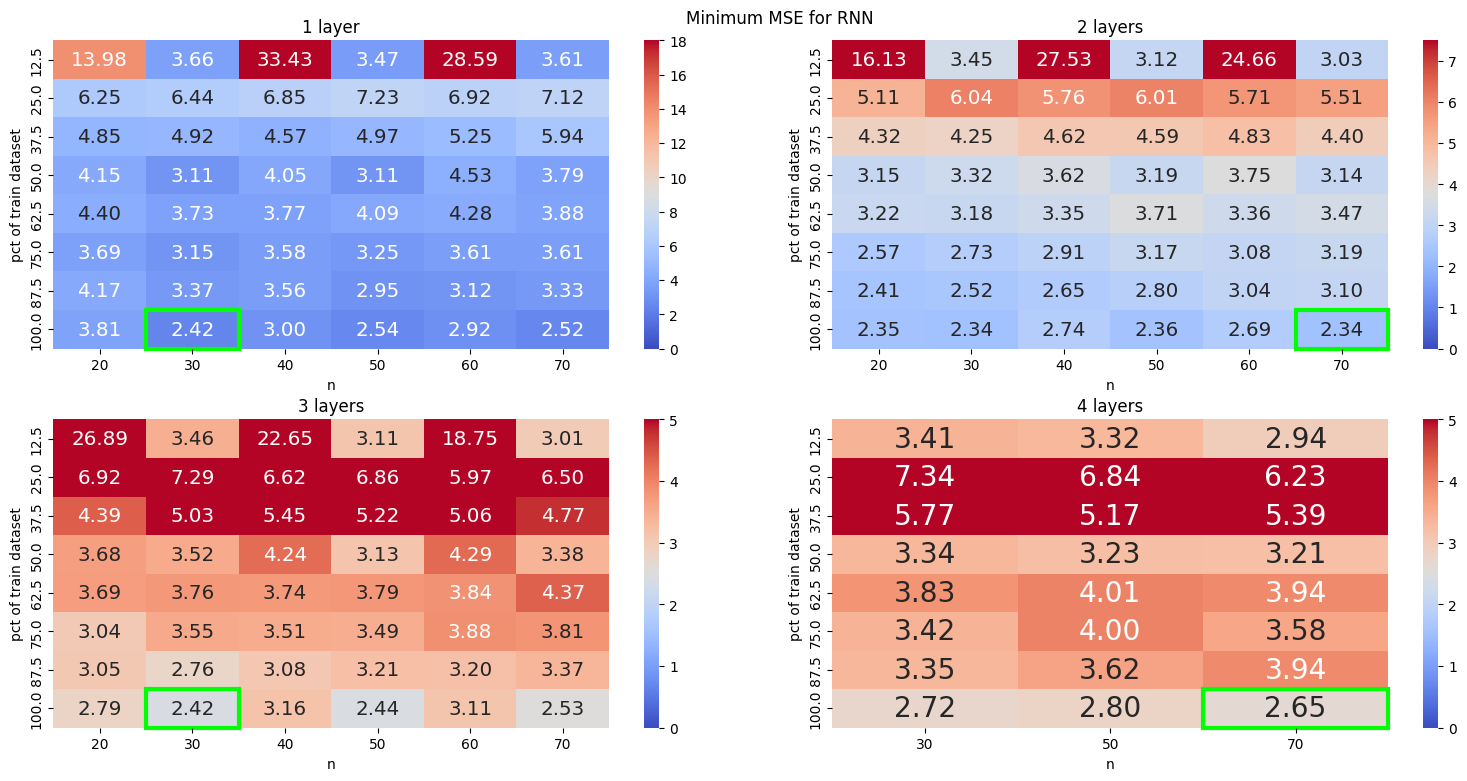

In [4]:
# tests mean and min, layers together, RNN
# %matplotlib inline
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = False
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })
# else:
#     # %matplotlib inline
#     import matplotlib
#     print(matplotlib.get_backend())
#     matplotlib.rcParams.update(matplotlib.rcParamsDefault)


models = ["rand"]
# models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
models_title = ["RNN"]
folder = "./results/final_datasets_rnn/"
result_files = [folder + file for file in os.listdir(folder) if ".txt" in file and "_results" not in file]

# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

mean_vmaxs = [0, 20, 10, 7.5, 7.5]
min_vmaxs = [0, 18, 7.5, 5, 5]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if folder in file
           and ("results_" + model + "_2024") in file]
    
    # print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [", ".join(arch.split(", ")[1:]).strip("[]") for arch in df['Architechture']]
            df.insert(1, 'n', [int(arch[1:].split(", ")[0]) for arch in df['Architechture']])
            df.insert(1, 'h', [row['Architechture'].count(str(row["n"])) for _, row in df[['Architechture', 'n']].iterrows()])
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    # mean_fig, mean_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    print(len(set(dfs_concat["h"])))
    mean_fig, mean_ax = plt.subplots(2, len(set(dfs_concat["h"]))//2, figsize=(16, 8))
    mean_ax = mean_ax.flatten()
    mean_fig.tight_layout(pad=3)
    mean_fig.suptitle(f"Mean MSE for {models_title[i]}")
    # min_fig, min_ax = plt.subplots(1, len(set(dfs_concat["h"])), figsize=(28, 4))
    min_fig, min_ax = plt.subplots(2, len(set(dfs_concat["h"]))//2, figsize=(16, 8))
    min_fig.tight_layout(pad=3)
    min_ax = min_ax.flatten()
    min_fig.suptitle(f"Minimum MSE for {models_title[i]}")
    for j, h in enumerate(set(dfs_concat["h"])):
        if h > 1: s = 's'
        else: s = ''
        mean_ax[j].set_title(f"{h} layer{s}")
        min_ax[j].set_title(f"{h} layer{s}")
        
        # try:
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=mean_ax[j], vmin=0, vmax=mean_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        print(f'{h}L min_idx {min_idx}')
        print('min_err:', heatmap_data.loc[row_idx, col_idx], '; rel_err', heatmap_data.loc[row_idx, col_idx] / 1.255)
        mean_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min')
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=min_ax[j], vmin=0, vmax=min_vmaxs[h], annot_kws={"size": 35 / np.sqrt(len(heatmap_data.columns))})
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        min_ax[j].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min', fill_value=True)
        # heatmap_data.replace(True, np.nan, inplace=True)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], vmin=0, vmax=vmaxs[h])
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[1].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        # # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc=np.argmin)
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count')
        # # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='std')
        # # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.0f', ax=ax[2], vmin=0)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[2], vmin=0)
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[2].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # except Exception as e:
        #     print("failed plots:", e)
        #     continue

        mean_ax[j].set_xlabel('n')
        mean_ax[j].set_ylabel(r'% of train dataset')
    # print(" ", file)

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[0].lower()}_plots')
        # print(plots_folder)
        if not os.path.exists(plots_folder): os.mkdir(plots_folder)
        # if isinstance(ax, plt.Axes):
        #     fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_min_mae.pgf")
        # else:
        #     fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_all.pgf")
        mean_fig.savefig(plots_folder + f"/{models_title[0].lower()}_mean_mea.pgf")
        min_fig.savefig(plots_folder + f"/{models_title[0].lower()}_min_mea.pgf")


# plt.show()


In [3]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

save_as_pgf = True
if save_as_pgf:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'sans-serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

models = ["rand"]
# # models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
# models_title = ["RNN"]
# folder = "./results/final_datasets_rnn/"
# result_files = [folder + file for file in os.listdir(folder) if ".txt" in file and "_results" not in file]
    # ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# models = ["diff_rand"]
# models_title = ["FNN6"]
# result_files = ["./results/final_datasets3/results_diff_rand_2024-04-09T130207.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-10T101624.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-11T114825.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-12T114550.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-12T130323.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-13T100152.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-13T191150.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-14T231148.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-15T110531.txt"
#                 ]

models_title = ["FNN3"]
folder = "./results/final_datasets3/"
result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

vmaxs = [0, 20, 10, 7.5, 7.5]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if folder in file
           and ("results_" + model + "_2024") in file]
    
    # result_files3 = [file for file in result_files if "./results/final_datasets3/" in file
    #        and ("results_" + model + "_2024") in file]
    
    print('\n'.join(result_files2), '\n')
    # print('\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2]# + \
        # [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [", ".join(arch.split(", ")[1:]).strip("[]") for arch in df['Architechture']]
            df.insert(1, 'n', [int(arch[1:].split(", ")[0]) for arch in df['Architechture']])
            df.insert(1, 'h', [row['Architechture'].count(str(row["n"])) for _, row in df[['Architechture', 'n']].iterrows()])
        except Exception as e:
            # print(df_tup[0])
            # print(df_tup[1])
            print("df processing failed:", e)
            # sys.exit()


    try:
        dfs_concat = pd.concat([el[1] for el in dfs], ignore_index=True, axis=0)
    except Exception as e:
        print("failed concat:", e)
        continue

    for h in set(dfs_concat["h"]):
        # fig, ax = plt.subplots(1, 3, figsize=(28, 4))
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        if h > 1: s = 's'
        else: s = ''
        # fig.suptitle(f"Data: {models_title[i]}, Results for {h} layer{s}")
        fig.suptitle(f"{models_title[i]}, Results for {h} layer{s}")
        # ax[0].set_title('Mean of tests')
        # ax[1].set_title('Minimum Test MAE [mm]')
        # # ax[2].set_title('Std. Deviation of tests')
        # ax[2].set_title('Num of tests')
        ax.set_title('Minimum Test MAE [mm]')
        
        # try:
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='mean')
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[0], vmin=0, vmax=vmaxs[h])
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[0].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='min', fill_value=True)
        heatmap_data.replace(True, np.nan, inplace=True)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], vmin=0, vmax=vmaxs[h])
        sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax, vmin=0, vmax=vmaxs[h])
        min_idx = heatmap_data.stack().idxmin()
        row_idx, col_idx = min_idx
        # ax[1].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        ax.add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc=np.argmin)
        # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='count').astype(int, errors='ignore')
        # # heatmap_data = dfs_concat[dfs_concat['h'] == h].pivot_table(index='pct of train dataset', columns='n', values='MAE [mm]', aggfunc='std')
        # # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.0f', ax=ax[2], vmin=0)
        # sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', ax=ax[2], vmin=0)
        # min_idx = heatmap_data.stack().idxmin()
        # row_idx, col_idx = min_idx
        # ax[2].add_patch(patches.Rectangle((heatmap_data.columns.get_loc(col_idx), heatmap_data.index.get_loc(row_idx)), 1, 1, fc='none', ec='lime', lw=3, clip_on=False))
        # except Exception as e:
        #     print("failed plots:", e)
        #     continue

    ax.set_xlabel('n')
    ax.set_ylabel(r'% of train dataset')

    # ax[0].set_xlabel('n')
    # ax[0].set_ylabel(r'% of train dataset')
    # ax[1].set_xlabel('n')
    # ax[1].set_ylabel(r'% of train dataset')
    # ax[2].set_xlabel('n')
    # ax[2].set_ylabel(r'% of train dataset')
    # print(" ", file)

    if save_as_pgf:
        plots_folder = os.path.join(folder, f'{models_title[0]}_plots')
        # print(plots_folder)
        if not os.path.exists(plots_folder): os.mkdir(plots_folder)
        if isinstance(ax, plt.Axes):
            fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_min_mae.pgf")
        else:
            fig.savefig(plots_folder + f"/{models_title[0].lower()}_{h}_all.pgf")


models: rand
./results/final_datasets3/results_rand_2024-03-25T112649.txt
./results/final_datasets3/results_rand_2024-03-25T222051.txt
./results/final_datasets3/results_rand_2024-03-26T112415.txt
./results/final_datasets3/results_rand_2024-03-27T153256.txt
./results/final_datasets3/results_rand_2024-03-27T201424.txt
./results/final_datasets3/results_rand_2024-04-03T151839.txt 



In [11]:
# FIND BEST FNN Model

import os
import sys
import pandas as pd
import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

# models = ["rand", "diff_rand", "diff_rand3N"]
# models = ["rand"]
# models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
# result_files = ["./results/final_datasets2/" + file for file in os.listdir("./results/final_datasets2") if ".txt" in file and "_results" not in file] + \
#     ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]
# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# models = ["diff_rand"]
# result_files = ["./results/final_datasets3/results_diff_rand_2024-04-09T130207.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-10T101624.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-11T114825.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-12T114550.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-12T130323.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-13T100152.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-13T191150.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-14T231148.txt",
#                 "./results/final_datasets3/results_diff_rand_2024-04-15T110531.txt"
#                 ]
# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)


models = ["rand"]
# folder = "./results/final_datasets3/"
result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

vmaxs = [0, 20, 10, 7.5, 7.5]

for i, model in enumerate(models):
    print("models:", model)
    # result_files2 = []
    result_files2 = [file for file in result_files if "./results/final_datasets2/" in file
           and ("results_" + model + "_2024") in file]
    
    result_files3 = [file for file in result_files if "./results/final_datasets3/" in file
           and ("results_" + model + "_2024") in file]
    
    print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    print('\n'.join(result_files), '\n')
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    best_model_error = 100
    best_model = ("", "", "")
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] + \
        [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]
        except:
            print(df_tup[0])
            print(df_tup[1])
            # sys.exit()

        df.insert(1, 'h', list(map(len, df['Architechture'])))
        df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

        min_model_idx = df["MAE [mm]"].idxmin()
        print(df.sort_values("MAE [mm]")[:4].loc[:,["Architechture", "pct of train dataset", "MAE [mm]"]])
        if (min_model_error := df.loc[min_model_idx, "MAE [mm]"]) < best_model_error:
            best_model_error = min_model_error
            best_model = (df_tup[0],
                          df.loc[min_model_idx, 'Architechture'],
                          df.loc[min_model_idx, 'pct of train dataset'],)
                        #   df.loc[min_model_idx, 'MAE [mm]'],
                        #   best_model_error)


    print(best_model, best_model_error)
           

models: rand
 
 ./results/final_datasets3/results_rand_2024-03-25T112649.txt
./results/final_datasets3/results_rand_2024-03-25T222051.txt
./results/final_datasets3/results_rand_2024-03-26T112415.txt
./results/final_datasets3/results_rand_2024-03-27T153256.txt
./results/final_datasets3/results_rand_2024-03-27T201424.txt
./results/final_datasets3/results_rand_2024-04-03T151839.txt
./results/final_datasets3/results_rand_2024-03-25T112649.txt
./results/final_datasets3/results_rand_2024-03-25T222051.txt
./results/final_datasets3/results_rand_2024-03-26T112415.txt
./results/final_datasets3/results_rand_2024-03-27T153256.txt
./results/final_datasets3/results_rand_2024-03-27T201424.txt
./results/final_datasets3/results_diff_rand_2024-03-28T140443.txt
./results/final_datasets3/results_diff_rand_2024-03-28T155400.txt
./results/final_datasets3/results_rand_2024-04-03T151839.txt
./results/final_datasets3/results_diff_rand_2024-04-05T112646.txt
./results/final_datasets3/results_diff_rand_2024-04-09

In [2]:
# FIND BEST RNN Model

import os
import sys
import pandas as pd
import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

labels2 = f'Architechture;pct of train dataset;Epochs;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]'.split(';')

dfs = []

# models = ["rand", "diff_rand", "diff_rand3N"]
models = ["rand"]
models_title = ["Random Points", "Random Points and Direction Vector", "Points w/ Nieghbours and Direction Vector"]
result_files = ["./results/final_datasets_rnn/" + file for file in os.listdir("./results/final_datasets_rnn") if ".txt" in file and "_results" not in file]
# result_files = ["./results/final_datasets3/" + file for file in os.listdir("./results/final_datasets3") if ".txt" in file and "_results" not in file]

# for file in result_files:
    # print(file)
# for df in dfs:
#     df['Architechture'] = [tuple(map(int, arch.split('[')[1].strip(']').split(', '))) for arch in df['Architechture']]

#     df.insert(1, 'h', list(map(len, df['Architechture'])))
#     df.insert(1, 'n', [arch[0] for arch in df['Architechture']])

#     print(df.shape)

vmaxs = [0, 20, 10, 7.5, 7.5]

for i, model in enumerate(models):
    print("models:", model)
    result_files2 = []
    # result_files2 = [file for file in result_files if "./results/final_datasets2/" in file
    #        and ("results_" + model + "_2024") in file]
    
    result_files3 = [file for file in result_files if "./results/final_datasets_rnn/" in file
           and ("results_" + model + "_2024") in file]
    
    # print('\n'.join(result_files2), '\n', '\n'.join(result_files3))
    # plt.show()
    # print("results_" + model + "_2024")
    # for file in result_files:
    best_model_error = 100
    best_model = ("", "", "")
    dfs = []
    dfs = [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files2] + \
        [(file, pd.read_csv(file, header=3, sep=';', index_col=None)) for file in result_files3]
    for j, df_tup in enumerate(dfs):
        df = df_tup[1]
        # print(result_files[j])
        # print(df.iloc[0])
        # print(df.shape)
        # print(df.columns)
        try:
            df['Architechture'] = [", ".join(arch.split(", ")[1:]).strip("[]") for arch in df['Architechture']]
            df.insert(1, 'n', [int(arch[1:].split(", ")[0]) for arch in df['Architechture']])
            df.insert(1, 'h', [row['Architechture'].count(str(row["n"])) for _, row in df[['Architechture', 'n']].iterrows()])
        except Exception as e:
            print("DF processing failed:", e)
            print(df_tup[0])
            print(df_tup[1])
            # sys.exit()

        min_model_idx = df["MAE [mm]"].idxmin()
        # print(df.sort_values("MAE [mm]")[:10].loc[:,["Architechture", "pct of train dataset", "MAE [mm]"]])
        if (min_model_error := df.loc[min_model_idx, "MAE [mm]"]) < best_model_error:
            best_model_error = min_model_error
            best_model = (df_tup[0],
                          df.loc[min_model_idx, 'Architechture'],
                          df.loc[min_model_idx, 'pct of train dataset'],
                        #   df.loc[min_model_idx, 'MAE [mm]'],
                          best_model_error)


    print(best_model)
    # print(df.shape)
    # print(df.head())

models: rand
('./results/final_datasets_rnn/results_rand_2024-04-03T155223.txt', '(70, False), (70, False)', 100.0, 2.336)
